# ================================================================
# Road Accident Data – UK 2021
# Professional Exploratory Data Analysis (EDA)
# Dataset: UK Road Safety Data – London Districts
# Goal: Understand accident patterns, severity factors,
#        and derive actionable road safety insights
# ================================================================

##1) Imports & Global Settings


In [2]:
# 1. Imports & Settings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import chi2_contingency

# ---- Global Style ----
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

RANDOM_STATE = 42

##2) Data Loading & Initial Inspection


In [3]:
# 2.1 Load data directly from Google Sheets (exported as CSV)
# OR load local CSV if downloaded

url = "https://docs.google.com/spreadsheets/d/1pvEDg-5IuhKyvQFTkJExEuPslSGzRkkpwld7P1WQk-Y/export?format=csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head()

Shape: (307973, 23)


,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [4]:
# 2.2 Column names overview
print(df.columns.tolist())

['Accident_Index', 'Accident Date', 'Month', 'Day_of_Week', 'Year', 'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions', 'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type']


In [5]:
# 2.3 Data types & non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Month                       307973 non-null  object 
 3   Day_of_Week                 307973 non-null  object 
 4   Year                        307973 non-null  int64  
 5   Junction_Control            307973 non-null  object 
 6   Junction_Detail             307973 non-null  object 
 7   Accident_Severity           307973 non-null  object 
 8   Latitude                    307973 non-null  float64
 9   Light_Conditions            307973 non-null  object 
 10  Local_Authority_(District)  307973 non-null  object 
 11  Carriageway_Hazards         5424 non-null    object 
 12  Longitude                   307973 non-null  float64
 13  Number_of_Casu

In [6]:
# 2.4 Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing_Count": missing, "Missing_%": missing_pct})
missing_df[missing_df["Missing_Count"] > 0].sort_values("Missing_%", ascending=False)

,Missing_Count,Missing_%
Carriageway_Hazards,302549,98.24
Weather_Conditions,6057,1.97
Road_Type,1534,0.50
Road_Surface_Conditions,317,0.10
Time,17,0.01


In [7]:
# 2.5 Summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,307973.0,2021.468934,0.499035,2021.000000,2021.000000,2021.000000,2022.000000,2022.000000
Latitude,307973.0,52.487005,1.339011,49.914488,51.485248,52.225943,53.415517,60.598055
Longitude,307973.0,-1.368884,1.356092,-7.516225,-2.247937,-1.349258,-0.206810,1.759398
Number_of_Casualties,307973.0,1.356882,0.815857,1.000000,1.000000,1.000000,1.000000,48.000000
Number_of_Vehicles,307973.0,1.829063,0.710477,1.000000,1.000000,2.000000,2.000000,32.000000
Speed_limit,307973.0,38.866037,14.032933,10.000000,30.000000,30.000000,50.000000,70.000000


##3) Data Cleaning & Type Handling


In [8]:
# 3.1 Convert Accident_Date to datetime
df["Accident Date"] = pd.to_datetime(df["Accident Date"])

# 3.2 Extract useful time features
df["Hour"] = df["Time"].str.split(":").str[0].astype(float)
df["DayType"] = df["Day_of_Week"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

# 3.3 Encode Accident_Severity as numeric for correlation
severity_map = {"Slight": 1, "Serious": 2, "Fatal": 3}
df["Severity_Numeric"] = df["Accident_Severity"].map(severity_map)

# 3.4 Drop duplicates if any
df = df.drop_duplicates().reset_index(drop=True)

print(f"Clean dataset shape: {df.shape}")
df.head(3)

Clean dataset shape: (307972, 26)


,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Hour,DayType,Severity_Numeric
0,200901BS70001,2021-01-01,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,Dry,One way street,30,15:11,Urban,Fine no high winds,Car,15.0,Weekday,2
1,200901BS70002,2021-01-05,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car,10.0,Weekday,2
2,200901BS70003,2021-01-04,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car,14.0,Weekend,1


In [9]:
# 4. Print a clean data dictionary

data_dict = {
    "Accident_Index":               "Unique identifier for each accident record.",
    "Accident Date":                "Date on which the accident occurred.",
    "Month":                        "Calendar month of the accident (Jan–Dec).",
    "Day_of_Week":                  "Day of the week on which the accident occurred.",
    "Year":                         "Calendar year of the accident.",
    "Junction_Control":             "Type of traffic control present at the junction.",
    "Junction_Detail":              "Physical type of junction where the accident occurred.",
    "Accident_Severity":            "Severity level of the accident: Slight, Serious, or Fatal.",
    "Latitude":                     "Geographic latitude coordinate of the accident location.",
    "Light_Conditions":             "Lighting conditions at the time of the accident.",
    "Local_Authority_(District)":   "Local administrative district where the accident occurred.",
    "Carriageway_Hazards":          "Any hazards present on the carriageway at the time.",
    "Longitude":                    "Geographic longitude coordinate of the accident location.",
    "Number_of_Casualties":         "Total number of casualties (injured or killed) in the accident.",
    "Number_of_Vehicles":           "Total number of vehicles involved in the accident.",
    "Police_Force":                 "Police force responsible for recording the accident.",
    "Road_Surface_Conditions":      "Condition of the road surface (e.g., Dry, Wet, Frost).",
    "Road_Type":                    "Type of road where the accident occurred.",
    "Speed_limit":                  "Posted speed limit at the accident location (mph).",
    "Time":                         "Time of day when the accident occurred (HH:MM).",
    "Urban_or_Rural_Area":          "Classification of the area as Urban or Rural.",
    "Weather_Conditions":           "Weather conditions at the time of the accident.",
    "Vehicle_Type":                 "Type of vehicle primarily involved in the accident.",
    # Engineered
    "Hour":                         "Hour of the day extracted from the Time column (0–23).",
    "DayType":                      "Whether the accident occurred on a Weekday or Weekend.",
    "Severity_Numeric":             "Numeric encoding of Accident_Severity (1=Slight, 2=Serious, 3=Fatal).",
}

dict_df = pd.DataFrame(
    list(data_dict.items()), columns=["Feature", "Description"]
)
dict_df.style.set_caption("Data Dictionary – Road Accident Dataset")

,Feature,Description
0,Accident_Index,Unique identifier for each accident record.
1,Accident Date,Date on which the accident occurred.
2,Month,Calendar month of the accident (Jan–Dec).
3,Day_of_Week,Day of the week on which the accident occurred.
4,Year,Calendar year of the accident.
5,Junction_Control,Type of traffic control present at the junction.
6,Junction_Detail,Physical type of junction where the accident occurred.
7,Accident_Severity,"Severity level of the accident: Slight, Serious, or Fatal."
8,Latitude,Geographic latitude coordinate of the accident location.
9,Light_Conditions,Lighting conditions at the time of the accident.


##5) Univariate Analysis
###5.1 Accident Severity Distribution


/tmp/ipykernel_222/2080893896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values,


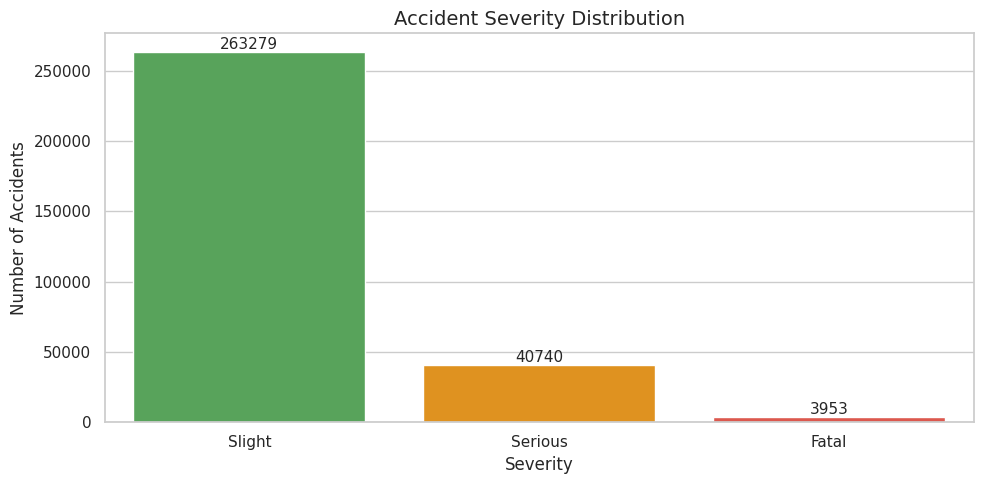

In [10]:
# 5.1 Target variable: Accident Severity

order = ["Slight", "Serious", "Fatal"]
counts = df["Accident_Severity"].value_counts().reindex(order)

plt.figure()
ax = sns.barplot(x=counts.index, y=counts.values,
                 palette=["#4caf50", "#ff9800", "#f44336"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

##5.2 Monthly Accident Trend


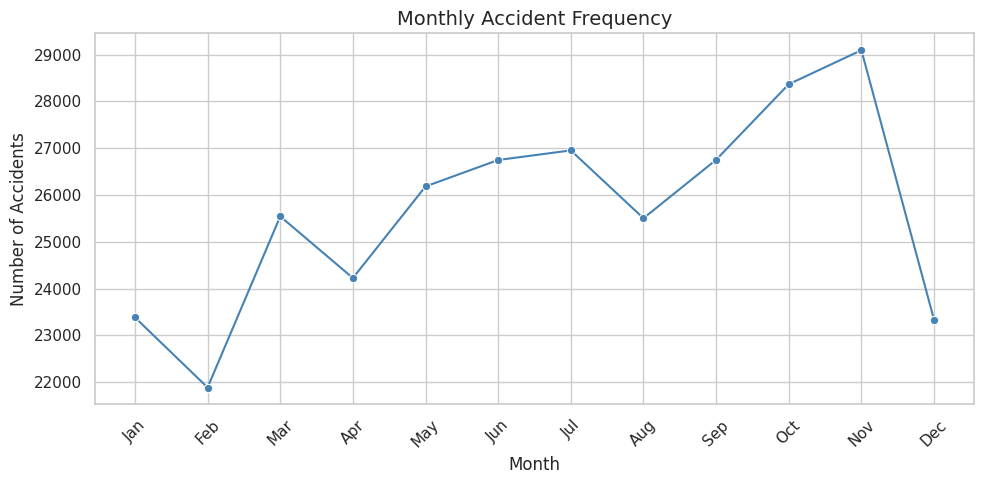

In [11]:
# 5.2 Accidents per month

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df["Month"].value_counts().reindex(month_order)

plt.figure()
sns.lineplot(x=monthly.index, y=monthly.values, marker="o", color="steelblue")
plt.title("Monthly Accident Frequency")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##5.3 Day of Week Distribution

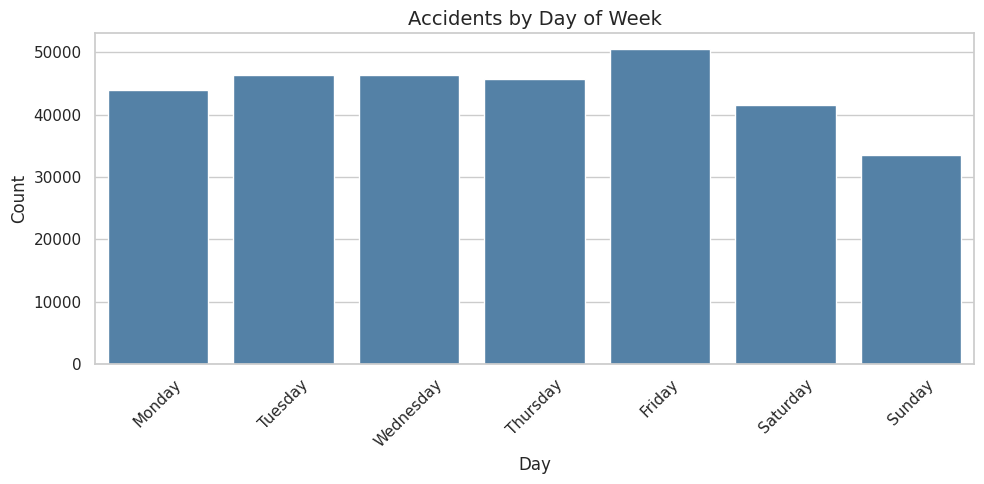

In [12]:
# 5.3 Accidents by day of week

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = df["Day_of_Week"].value_counts().reindex(day_order)

plt.figure()
sns.barplot(x=day_counts.index, y=day_counts.values, color="steelblue")
plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##5.4 Accidents by Hour of Day


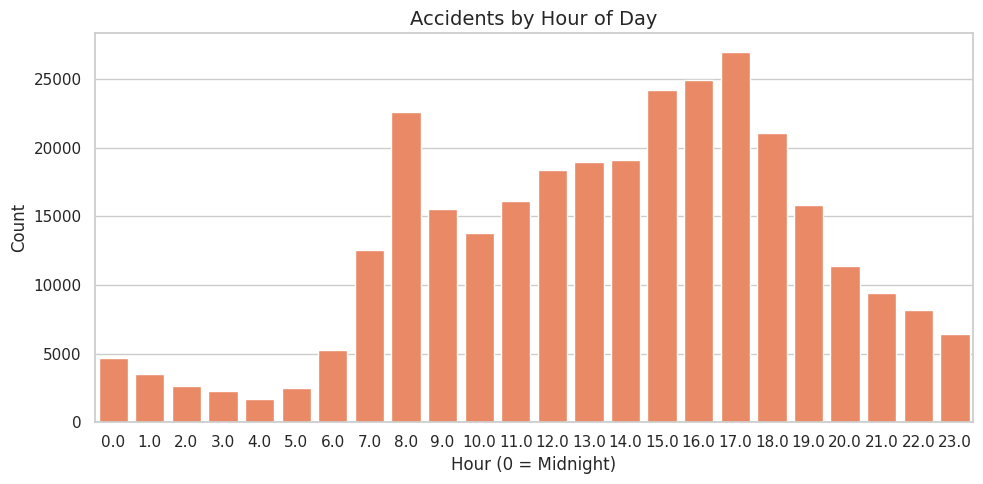

In [13]:
# 5.4 Hour distribution – peak accident times

hourly = df["Hour"].value_counts().sort_index()

plt.figure()
sns.barplot(x=hourly.index, y=hourly.values, color="coral")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour (0 = Midnight)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##5.5 Distribution of Casualties & Vehicles


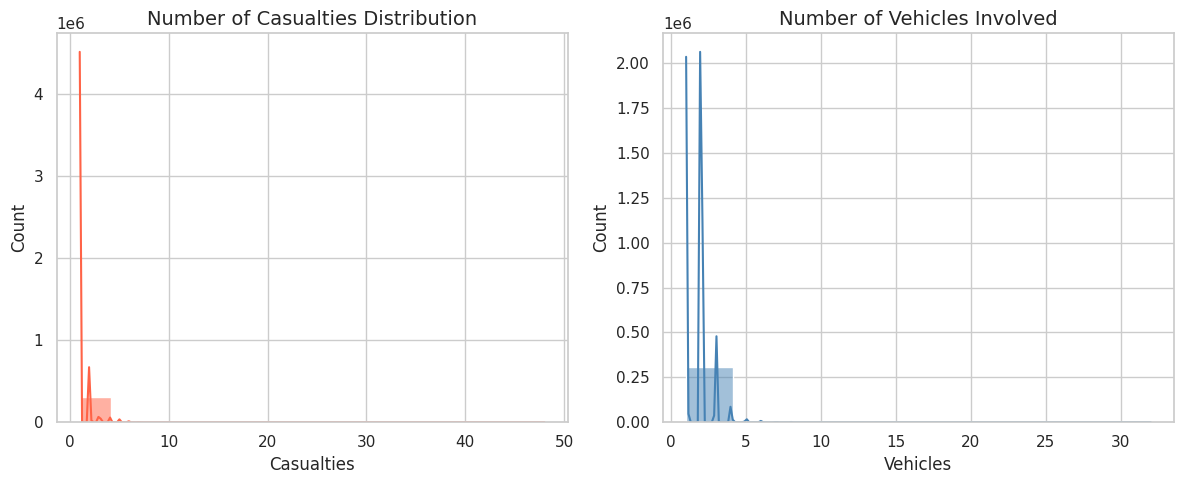

In [14]:
# 5.5 Histograms for numeric features

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Number_of_Casualties"], bins=15, kde=True, ax=axes[0], color="tomato")
axes[0].set_title("Number of Casualties Distribution")
axes[0].set_xlabel("Casualties")

sns.histplot(df["Number_of_Vehicles"], bins=10, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Number of Vehicles Involved")
axes[1].set_xlabel("Vehicles")

plt.tight_layout()
plt.show()

##5.6 Top Categorical Features


/tmp/ipykernel_222/2515419304.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="Blues_r")


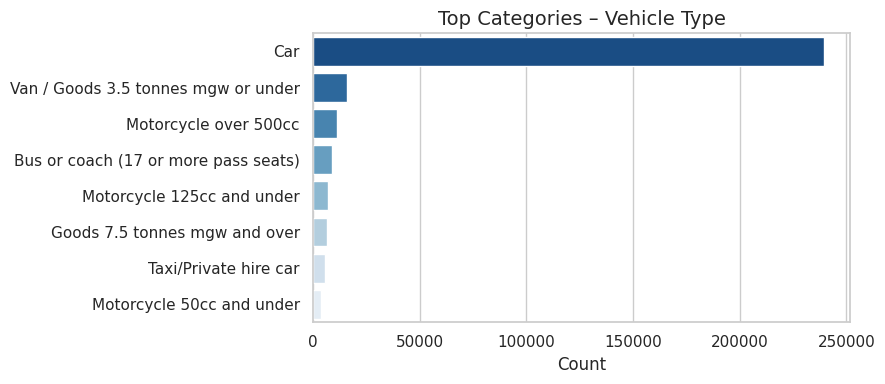

/tmp/ipykernel_222/2515419304.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="Blues_r")


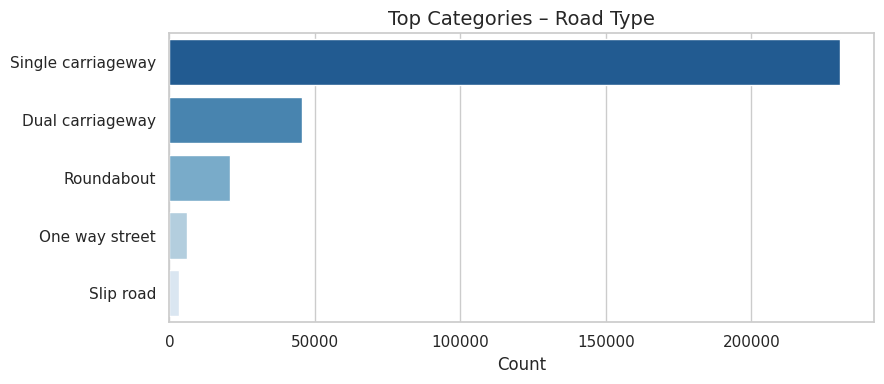

/tmp/ipykernel_222/2515419304.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="Blues_r")


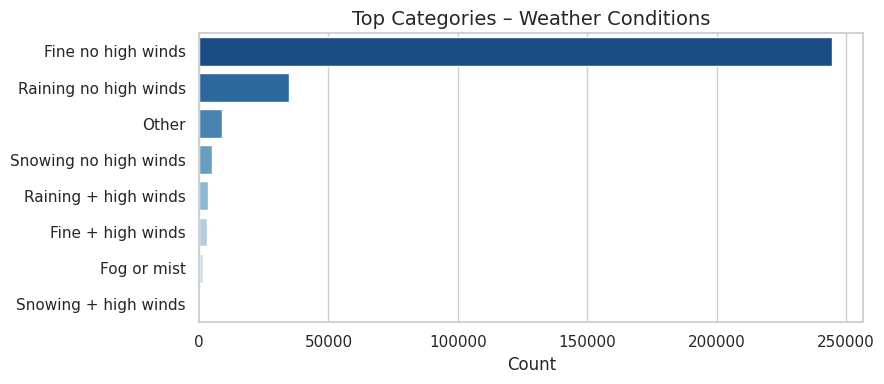

/tmp/ipykernel_222/2515419304.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="Blues_r")


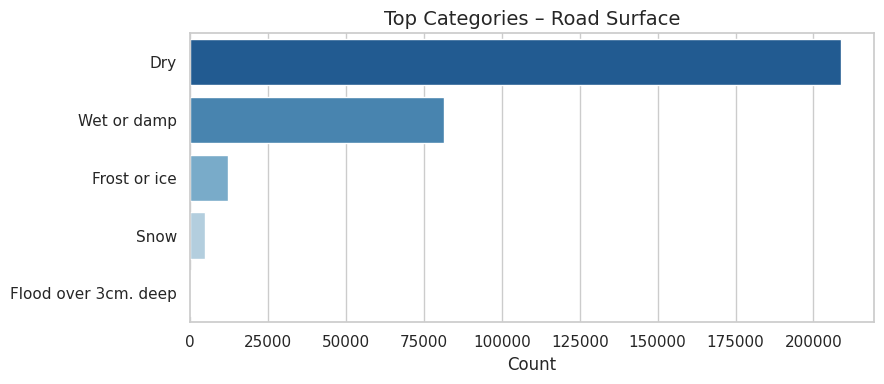

/tmp/ipykernel_222/2515419304.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="Blues_r")


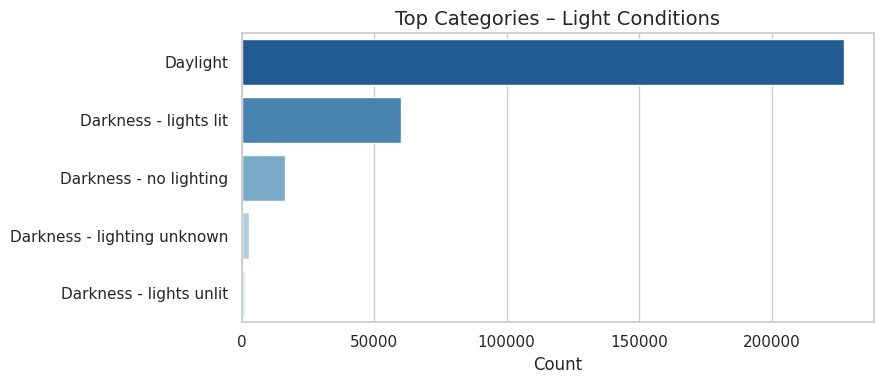

In [15]:
# 5.6 Vehicle Type, Road Type, Weather, Road Surface, Light Conditions

cat_features = {
    "Vehicle_Type":         "Vehicle Type",
    "Road_Type":            "Road Type",
    "Weather_Conditions":   "Weather Conditions",
    "Road_Surface_Conditions": "Road Surface",
    "Light_Conditions":     "Light Conditions",
}

for col, title in cat_features.items():
    counts = df[col].value_counts().head(8)
    plt.figure(figsize=(9, 4))
    sns.barplot(x=counts.values, y=counts.index, palette="Blues_r")
    plt.title(f"Top Categories – {title}")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

#6) Bivariate Analysis – Severity vs Each Feature


In [16]:
# Helper function: Churn rate equivalent for Severity

def severity_rate_plot(df, col, top_n=8, title=None):
    """Plot mean Severity_Numeric by category."""
    rate = (
        df.groupby(col)["Severity_Numeric"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
    )
    plt.figure(figsize=(9, 4))
    sns.barplot(x=rate.values, y=rate.index, palette="Reds_r")
    plt.title(title or f"Average Severity Score by {col}")
    plt.xlabel("Mean Severity (1=Slight, 2=Serious, 3=Fatal)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_222/2814614811.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette="Reds_r")


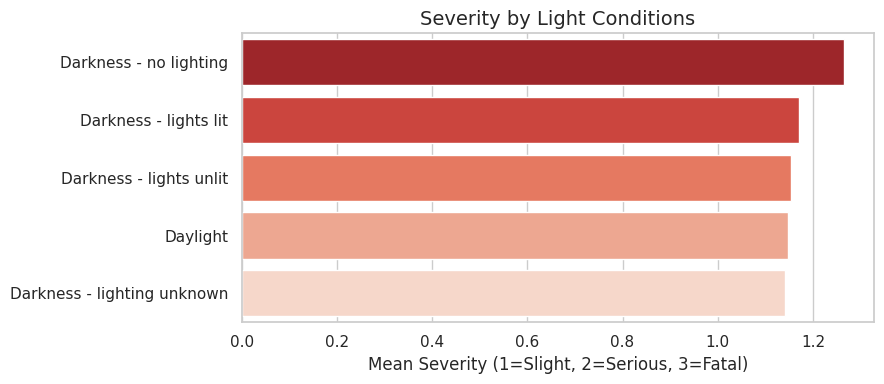

/tmp/ipykernel_222/2814614811.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette="Reds_r")


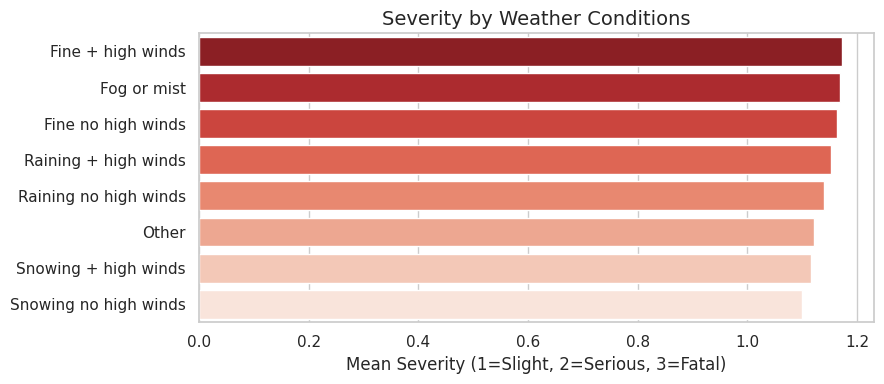

/tmp/ipykernel_222/2814614811.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette="Reds_r")


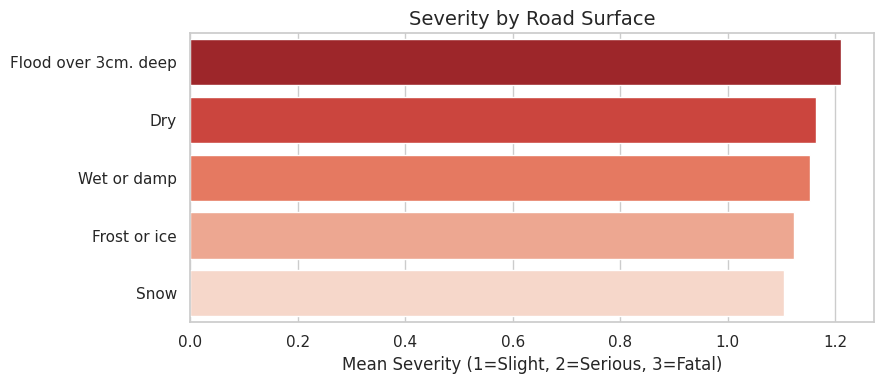

/tmp/ipykernel_222/2814614811.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette="Reds_r")


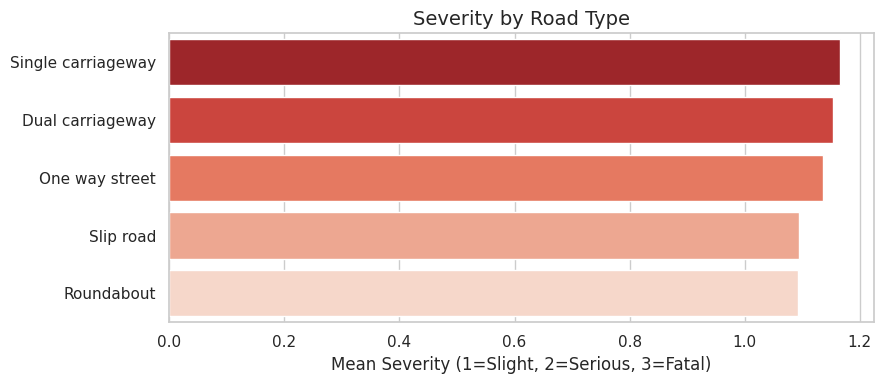

/tmp/ipykernel_222/2814614811.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette="Reds_r")


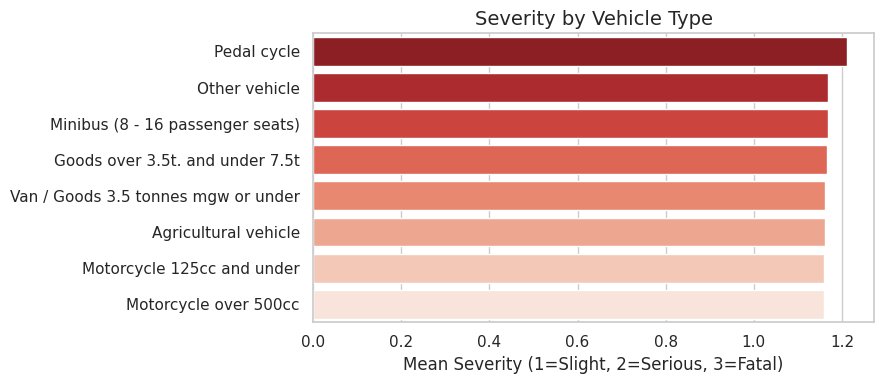

/tmp/ipykernel_222/2814614811.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette="Reds_r")


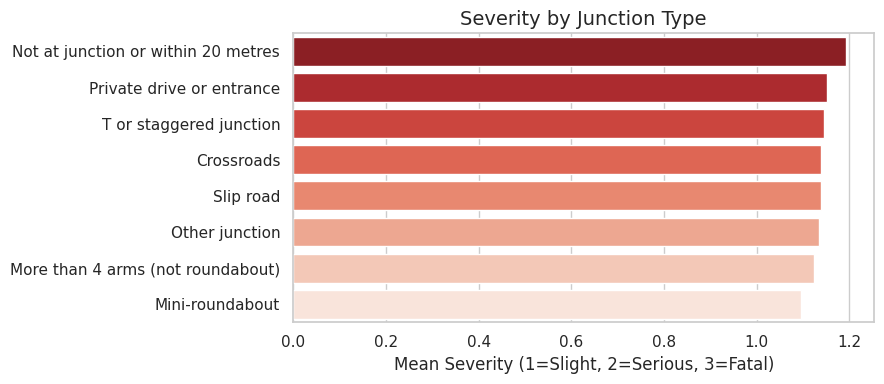

/tmp/ipykernel_222/2814614811.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette="Reds_r")


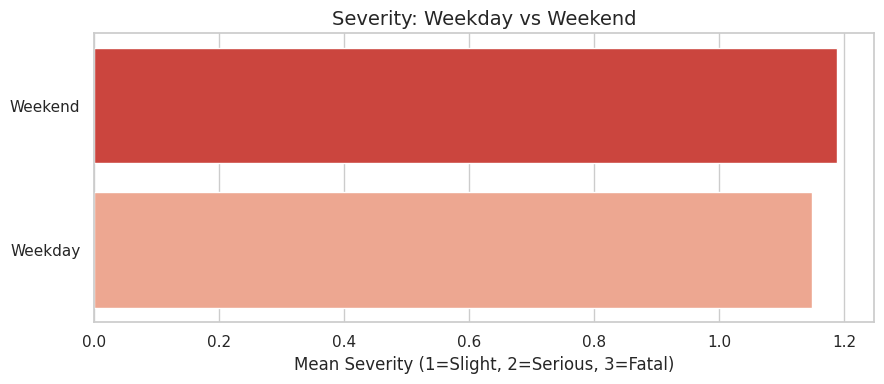

In [17]:
# 6.1 Severity vs Light Conditions
severity_rate_plot(df, "Light_Conditions", title="Severity by Light Conditions")

# 6.2 Severity vs Weather
severity_rate_plot(df, "Weather_Conditions", title="Severity by Weather Conditions")

# 6.3 Severity vs Road Surface
severity_rate_plot(df, "Road_Surface_Conditions", title="Severity by Road Surface")

# 6.4 Severity vs Road Type
severity_rate_plot(df, "Road_Type", title="Severity by Road Type")

# 6.5 Severity vs Vehicle Type
severity_rate_plot(df, "Vehicle_Type", title="Severity by Vehicle Type")

# 6.6 Severity vs Junction Detail
severity_rate_plot(df, "Junction_Detail", title="Severity by Junction Type")

# 6.7 Severity vs DayType
severity_rate_plot(df, "DayType", title="Severity: Weekday vs Weekend")

/tmp/ipykernel_222/3227734144.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Accident_Severity", y="Number_of_Casualties",


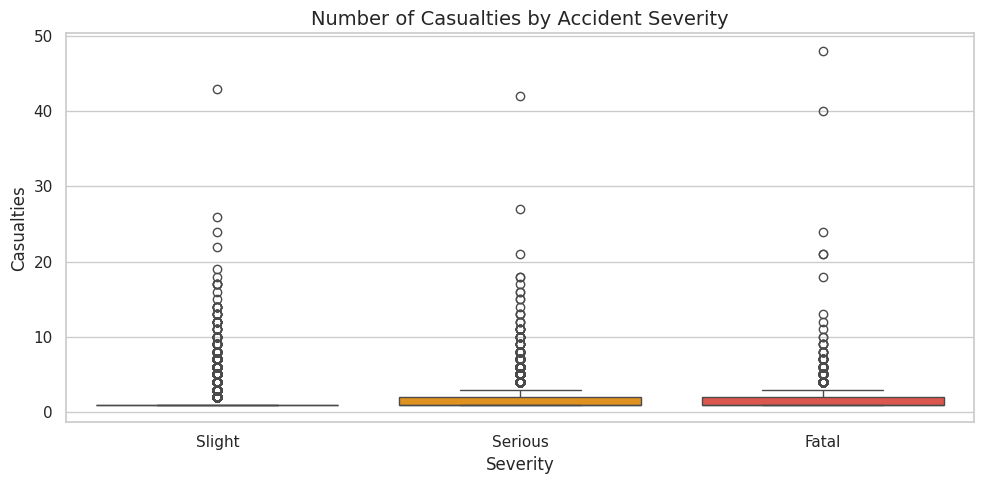

In [18]:
# 6.8 Casualties vs Severity (Boxplot)

plt.figure()
sns.boxplot(x="Accident_Severity", y="Number_of_Casualties",
            data=df, order=["Slight","Serious","Fatal"],
            palette=["#4caf50","#ff9800","#f44336"])
plt.title("Number of Casualties by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Casualties")
plt.tight_layout()
plt.show()


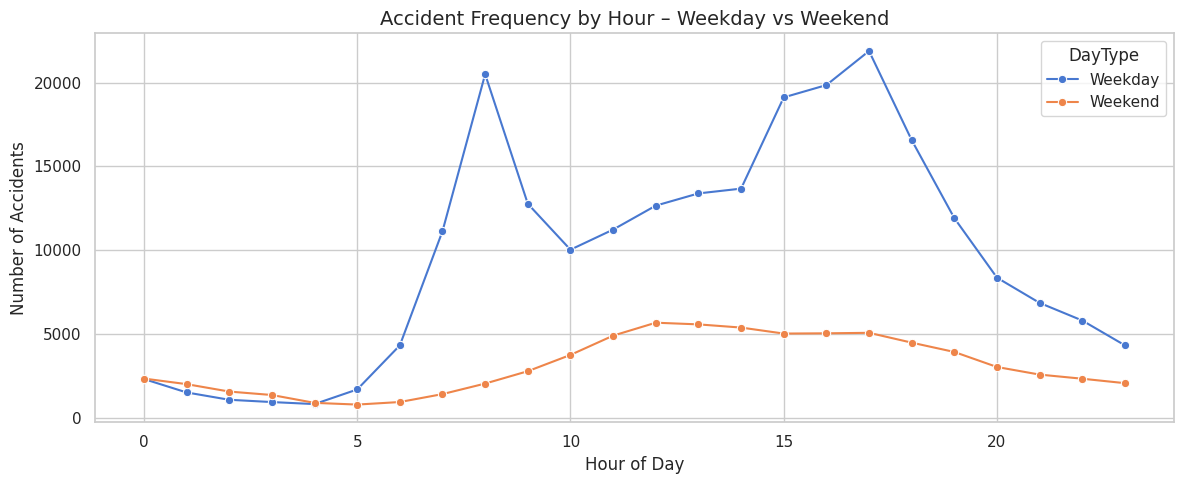

In [19]:
# 6.9 Accidents by Hour × DayType

hour_day = df.groupby(["Hour","DayType"]).size().reset_index(name="Count")

plt.figure(figsize=(12, 5))
sns.lineplot(data=hour_day, x="Hour", y="Count", hue="DayType", marker="o")
plt.title("Accident Frequency by Hour – Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

##7) Multivariate Analysis
###7.1 Correlation Heatmap

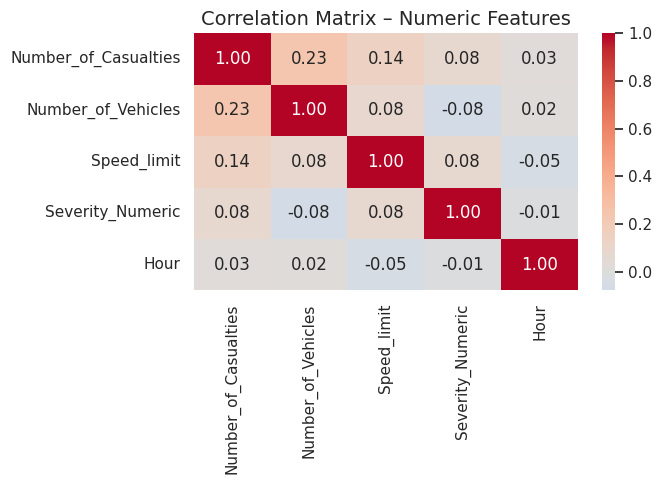

In [20]:
# 7.1 Correlation between numeric features

num_cols = ["Number_of_Casualties", "Number_of_Vehicles",
            "Speed_limit", "Severity_Numeric", "Hour"]

corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix – Numeric Features")
plt.tight_layout()
plt.show()


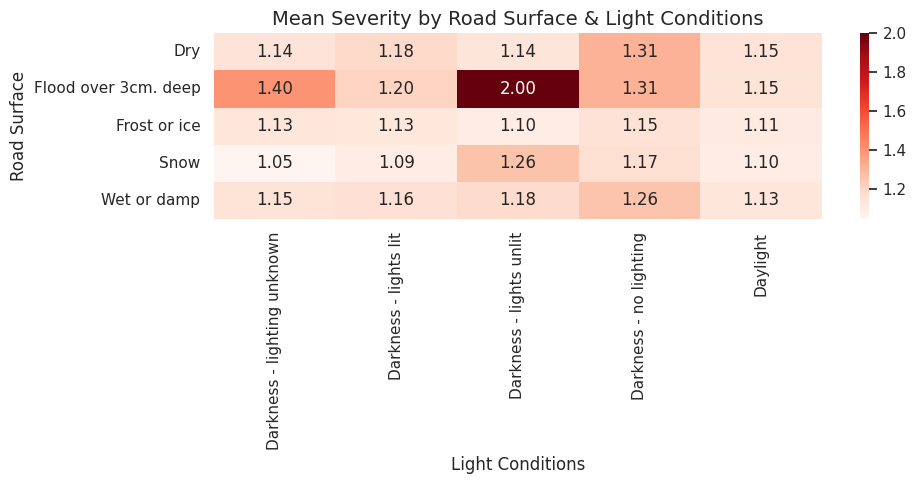

In [21]:
# 7.2 Severity rate by Road Surface & Light Conditions

pivot = df.pivot_table(
    index="Road_Surface_Conditions",
    columns="Light_Conditions",
    values="Severity_Numeric",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, cmap="Reds", fmt=".2f")
plt.title("Mean Severity by Road Surface & Light Conditions")
plt.ylabel("Road Surface")
plt.xlabel("Light Conditions")
plt.tight_layout()
plt.show()


Text(91.24999999999999, 0.5, 'Junction Detail')

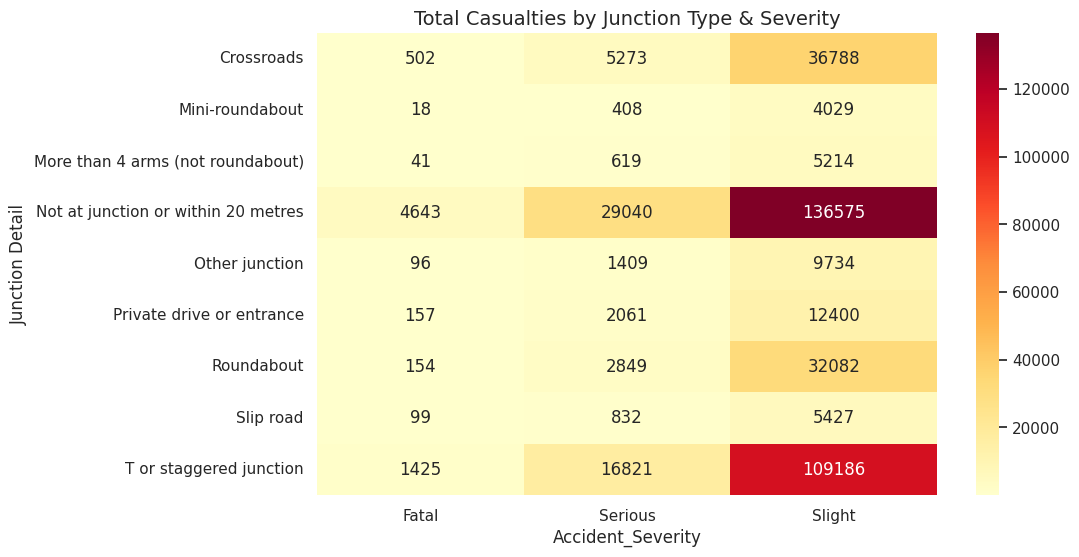

In [22]:
# 7.3 Severity by Junction Detail & Weather

pivot2 = df.pivot_table(
    index="Junction_Detail",
    columns="Accident_Severity",
    values="Number_of_Casualties",
    aggfunc="sum"
).fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot2, annot=True, cmap="YlOrRd", fmt=".0f")
plt.title("Total Casualties by Junction Type & Severity")
plt.ylabel("Junction Detail")


#Preprocessing & Feature Engineering

In [24]:
# ----------------------------------------------------------------
# 4. PREPROCESSING & FEATURE ENGINEERING
# ----------------------------------------------------------------

# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# 4.1 Extract hour of day from the Time column (format HH:MM)
#     This turns "14:30" into 14.0 – a useful numeric feature
df["Hour"] = df["Time"].str.split(":").str[0].astype(float)

# 4.2 Create binary DayType feature: Weekend=1, Weekday=0
#     Accidents may behave differently on weekends vs weekdays
df["DayType"] = df["Day_of_Week"].apply(
    lambda x: 1 if x in ["Saturday", "Sunday"] else 0
)

# 4.3 Define the feature columns to use in all models
feature_cols = [
    "Number_of_Casualties",       # total casualties in the accident
    "Number_of_Vehicles",         # total vehicles involved
    "Speed_limit",                # posted speed limit at location
    "Hour",                       # hour of day (0–23)
    "DayType",                    # 0=Weekday, 1=Weekend
    "Light_Conditions",           # daylight / darkness / etc.
    "Weather_Conditions",         # fine / rain / snow / etc.
    "Road_Surface_Conditions",    # dry / wet / frost / etc.
    "Road_Type",                  # single carriageway / dual / etc.
    "Junction_Detail",            # crossroads / T-junction / etc.
    "Vehicle_Type",               # car / motorcycle / bus / etc.
    "Urban_or_Rural_Area",        # Urban or Rural
]

# 4.4 Define the target column
target_col = "Accident_Severity"  # Slight / Serious / Fatal

# 4.5 Keep only relevant columns and drop rows with any NaN
df_ml = df[feature_cols + [target_col]].dropna().copy()
print(f"ML-ready dataset shape: {df_ml.shape}")

# 4.6 Encode all remaining categorical (object) feature columns
#     using LabelEncoder – converts string labels to integers
le_dict = {}   # store each encoder in case we need to inverse-transform later

for col in df_ml.select_dtypes(include="object").columns:
    if col != target_col:                          # skip the target column here
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        le_dict[col] = le                          # save the encoder

# 4.7 Encode the target column separately to preserve class names
le_target = LabelEncoder()
df_ml[target_col] = le_target.fit_transform(df_ml[target_col])

print(f"\nTarget class mapping : {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
print(f"Class distribution   :\n{df_ml[target_col].value_counts()}")

ML-ready dataset shape: (300494, 13)

Target class mapping : {'Fatal': np.int64(0), 'Serious': np.int64(1), 'Slight': np.int64(2)}
Class distribution   :
Accident_Severity
2    256518
1     40084
0      3892
Name: count, dtype: int64


##Train / Test Split

In [25]:
# ----------------------------------------------------------------
# 5. TRAIN / TEST SPLIT
# ----------------------------------------------------------------

# Import necessary modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) from target (y)
X = df_ml[feature_cols]   # feature matrix – shape (n_samples, n_features)
y = df_ml[target_col]     # target vector  – shape (n_samples,)

# Split into 80% training and 20% testing
# stratify=y ensures the same class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,           # 20% held out for evaluation
    random_state = RANDOM_STATE,  # reproducible split
    stratify     = y              # preserve class balance
)

print(f"Training set   : {X_train.shape}")
print(f"Test set       : {X_test.shape}")
print(f"Class balance  :\n{y_train.value_counts(normalize=True).round(3)}")

# ---- Scale features for SVM (done once, reused in Model 6) ----
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled   = scaler.transform(X_test)         # transform test only (no leakage)
X_scaled        = scaler.fit_transform(X)          # scaled full data for CV

Training set   : (240395, 12)
Test set       : (60099, 12)
Class balance  :
Accident_Severity
2    0.854
1    0.133
0    0.013
Name: proportion, dtype: float64


##Evaluation Helper Function

In [26]:
# ----------------------------------------------------------------
# 6. EVALUATION HELPER FUNCTION
# ----------------------------------------------------------------
# Centralised function to: predict, print all metrics,
# plot confusion matrix, and store results for final comparison.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

results_list = []   # accumulates one dict per model for final comparison

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained classifier on the test set.

    Parameters
    ----------
    model       : trained sklearn estimator
    X_test      : test feature matrix (raw or scaled)
    y_test      : true labels for the test set
    model_name  : string label used in output titles

    Returns
    -------
    y_pred : predicted labels array
    """

    # Generate predictions on the unseen test set
    y_pred = model.predict(X_test)

    # ── Core Metrics ──────────────────────────────────────────
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(   y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(       y_test, y_pred, average="weighted", zero_division=0)

    # ── Print Summary ─────────────────────────────────────────
    print(f"\n{'═'*58}")
    print(f"  {model_name}")
    print(f"{'═'*58}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  (weighted avg)")
    print(f"  Recall    : {rec:.4f}  (weighted avg)")
    print(f"  F1-Score  : {f1:.4f}  (weighted avg)")
    print(f"\n  Full Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names = le_target.classes_,
        zero_division = 0
    ))

    # ── Confusion Matrix Heatmap ──────────────────────────────
    cm     = confusion_matrix(y_test, y_pred)
    cm_df  = pd.DataFrame(cm, index=le_target.classes_, columns=le_target.classes_)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
    plt.title(f"Confusion Matrix – {model_name}", fontsize=13)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # ── Store Results for Final Comparison ────────────────────
    results_list.append({
        "Model"     : model_name,
        "Accuracy"  : acc,
        "Precision" : prec,
        "Recall"    : rec,
        "F1_Score"  : f1
    })

    return y_pred   # return predictions for any further analysis

##Model 1 – Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression – CV Accuracy: 0.8536 ± 0.0001

══════════════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════════════
  Accuracy  : 0.8536  (85.36%)
  Precision : 0.7788  (weighted avg)
  Recall    : 0.8536  (weighted avg)
  F1-Score  : 0.7864  (weighted avg)

  Full Classification Report:
              precision    recall  f1-score   support

       Fatal       1.00      0.00      0.00       778
     Serious       0.28      0.00      0.00      8017
      Slight       0.85      1.00      0.92     51304

    accuracy                           0.85     60099
   macro avg       0.71      0.33      0.31     60099
weighted avg       0.78      0.85      0.79     60099



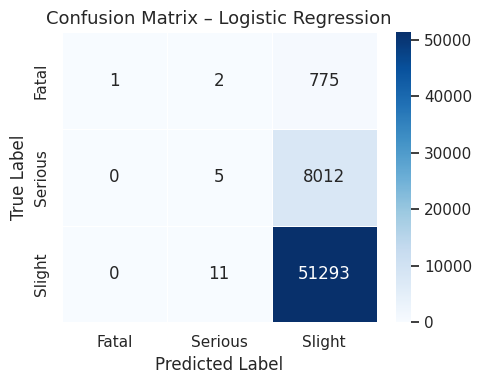

In [27]:
# ----------------------------------------------------------------
# MODEL 1 – LOGISTIC REGRESSION (Baseline Linear Classifier)
# ----------------------------------------------------------------
# Why: Provides a simple, interpretable linear baseline.
# max_iter increased to ensure convergence on multi-class data.
# ----------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression(
    max_iter     = 1000,          # max iterations for solver convergence
    solver       = "lbfgs",       # efficient solver for multiclass problems
    multi_class  = "auto",        # automatically selects OvR or multinomial
    random_state = RANDOM_STATE,
    n_jobs       = -1             # use all CPU cores
)

# Train on the training set
log_reg.fit(X_train, y_train)

# 5-Fold Cross-Validation on the full dataset for robust accuracy estimate
lr_cv = cross_val_score(log_reg, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"Logistic Regression – CV Accuracy: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")

# Evaluate on held-out test set
y_pred_lr = evaluate_model(log_reg, X_test, y_test, "Logistic Regression")

##Model 2 – Random Forest

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest – CV Accuracy: 0.8364 ± 0.0027

══════════════════════════════════════════════════════════
  Random Forest
══════════════════════════════════════════════════════════
  Accuracy  : 0.8367  (83.67%)
  Precision : 0.7611  (weighted avg)
  Recall    : 0.8367  (weighted avg)
  F1-Score  : 0.7884  (weighted avg)

  Full Classification Report:
              precision    recall  f1-score   support

       Fatal       0.07      0.01      0.02       778
     Serious       0.21      0.05      0.08      8017
      Slight       0.86      0.97      0.91     51304

    accuracy                           0.84     60099
   macro avg       0.38      0.34      0.34     60099
weighted avg       0.76      0.84      0.79     60099



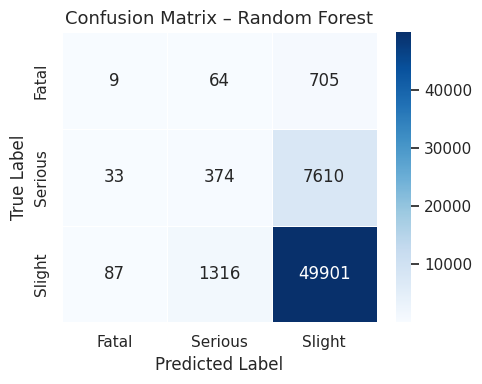

In [28]:
# ----------------------------------------------------------------
# MODEL 2 – RANDOM FOREST CLASSIFIER (Ensemble of Decision Trees)
# ----------------------------------------------------------------
# Why: Reduces overfitting vs a single tree by averaging 200 trees.
#      Provides reliable feature importance scores.
# ----------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators = 200,           # number of trees in the forest
    max_depth    = None,          # trees grow until all leaves are pure
    random_state = RANDOM_STATE,
    n_jobs       = -1             # parallel training across all CPU cores
)

rf.fit(X_train, y_train)

# 5-Fold Cross-Validation
rf_cv = cross_val_score(rf, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"Random Forest – CV Accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

# Evaluate
y_pred_rf = evaluate_model(rf, X_test, y_test, "Random Forest")

/tmp/ipykernel_222/3055876305.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, palette="Blues_r")


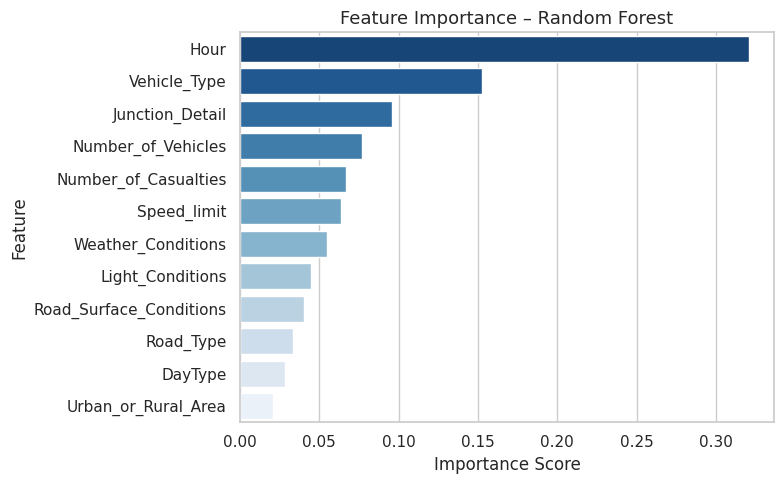

In [29]:
# ── Random Forest: Feature Importance ────────────────────────
# Shows which features contribute most to severity prediction

rf_importances = pd.Series(
    rf.feature_importances_,     # importance score per feature
    index = feature_cols
).sort_values(ascending=False)   # sort highest to lowest

plt.figure(figsize=(8, 5))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette="Blues_r")
plt.title("Feature Importance – Random Forest", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##Model 3 – Gradient Boosting

Gradient Boosting – CV Accuracy: 0.8536 ± 0.0001

══════════════════════════════════════════════════════════
  Gradient Boosting
══════════════════════════════════════════════════════════
  Accuracy  : 0.8538  (85.38%)
  Precision : 0.7870  (weighted avg)
  Recall    : 0.8538  (weighted avg)
  F1-Score  : 0.7871  (weighted avg)

  Full Classification Report:
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00       778
     Serious       0.43      0.00      0.01      8017
      Slight       0.85      1.00      0.92     51304

    accuracy                           0.85     60099
   macro avg       0.43      0.33      0.31     60099
weighted avg       0.79      0.85      0.79     60099



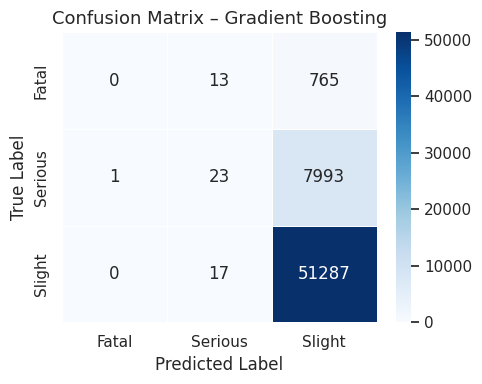

In [30]:
# ----------------------------------------------------------------
# MODEL 3 – GRADIENT BOOSTING CLASSIFIER
# ----------------------------------------------------------------
# Why: Builds trees sequentially where each tree corrects the
#      errors of the previous one. Strong performance on tabular
#      data with mixed feature types.
# Key params:
#   n_estimators  = number of boosting rounds (trees)
#   learning_rate = shrinkage applied to each tree's contribution
#   max_depth     = depth of each individual weak learner
# ----------------------------------------------------------------

from sklearn.ensemble import GradientBoostingClassifier

gbr = GradientBoostingClassifier(
    n_estimators  = 200,          # 200 sequential boosting rounds
    learning_rate = 0.05,         # small learning rate → slower but more robust
    max_depth     = 3,            # shallow trees act as weak learners
    subsample     = 0.8,          # use 80% of samples per tree (reduces variance)
    random_state  = RANDOM_STATE
)

# Train the model on the training set
gbr.fit(X_train, y_train)

# 5-Fold Cross-Validation to estimate generalisation accuracy
gbr_cv = cross_val_score(gbr, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"Gradient Boosting – CV Accuracy: {gbr_cv.mean():.4f} ± {gbr_cv.std():.4f}")

# Full evaluation: metrics + confusion matrix
y_pred_gbr = evaluate_model(gbr, X_test, y_test, "Gradient Boosting")

/tmp/ipykernel_222/3614634679.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gbr_importances.values, y=gbr_importances.index, palette="Oranges_r")


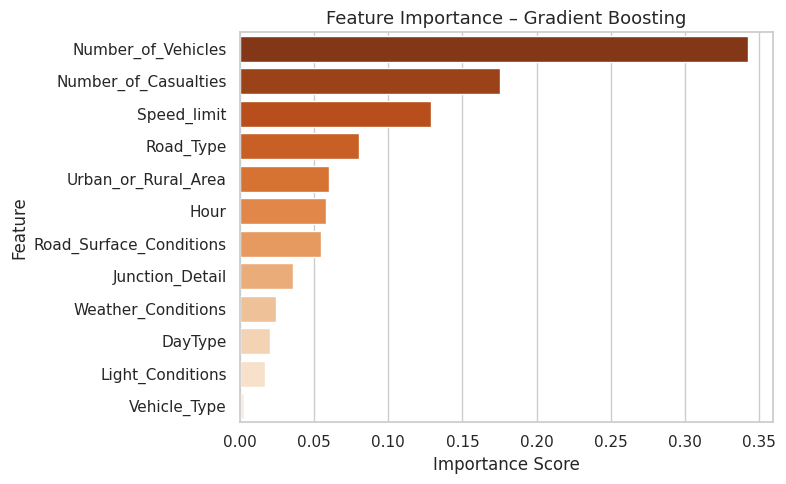

In [31]:
# ── Gradient Boosting: Feature Importance ─────────────────────
# Shows which features the boosting process relied on most

gbr_importances = pd.Series(
    gbr.feature_importances_,
    index = feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=gbr_importances.values, y=gbr_importances.index, palette="Oranges_r")
plt.title("Feature Importance – Gradient Boosting", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##Model 4 – KNN

KNN (k=7) – CV Accuracy: 0.8230 ± 0.0044

══════════════════════════════════════════════════════════
  KNN (k=7)
══════════════════════════════════════════════════════════
  Accuracy  : 0.8254  (82.54%)
  Precision : 0.7601  (weighted avg)
  Recall    : 0.8254  (weighted avg)
  F1-Score  : 0.7860  (weighted avg)

  Full Classification Report:
              precision    recall  f1-score   support

       Fatal       0.06      0.02      0.02       778
     Serious       0.20      0.07      0.10      8017
      Slight       0.86      0.96      0.90     51304

    accuracy                           0.83     60099
   macro avg       0.37      0.35      0.34     60099
weighted avg       0.76      0.83      0.79     60099



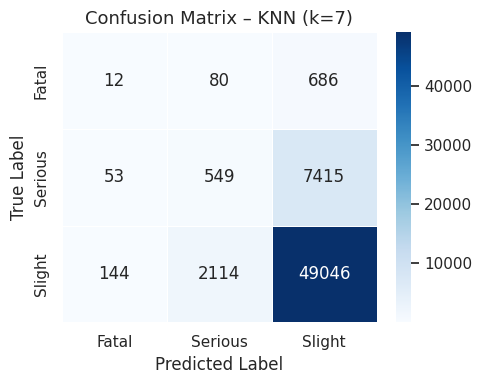

In [32]:
# ----------------------------------------------------------------
# MODEL 4 – K-NEAREST NEIGHBORS (KNN) CLASSIFIER
# ----------------------------------------------------------------
# Why: Non-parametric, instance-based classifier. Classifies each
#      sample based on the majority vote of its k closest neighbors
#      in feature space.
# Key params:
#   n_neighbors = k – number of neighbors to consider
#   weights     = "distance" → closer neighbors carry more weight
#   metric      = "minkowski" with p=2 → Euclidean distance
# ----------------------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors = 7,              # consider the 7 nearest neighbors
    weights     = "distance",     # weight votes by inverse distance
    metric      = "minkowski",    # generalised distance metric
    p           = 2,              # p=2 → Euclidean distance
    n_jobs      = -1              # use all CPU cores for neighbor search
)

# Train (memorise) the training set
knn.fit(X_train, y_train)

# 5-Fold Cross-Validation
knn_cv = cross_val_score(knn, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"KNN (k=7) – CV Accuracy: {knn_cv.mean():.4f} ± {knn_cv.std():.4f}")

# Full evaluation: metrics + confusion matrix
y_pred_knn = evaluate_model(knn, X_test, y_test, "KNN (k=7)")

##Model 5 – Decision Tree

Decision Tree – CV Accuracy: 0.8534 ± 0.0001

══════════════════════════════════════════════════════════
  Decision Tree
══════════════════════════════════════════════════════════
  Accuracy  : 0.8536  (85.36%)
  Precision : 0.7844  (weighted avg)
  Recall    : 0.8536  (weighted avg)
  F1-Score  : 0.7883  (weighted avg)

  Full Classification Report:
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00       778
     Serious       0.41      0.01      0.02      8017
      Slight       0.85      1.00      0.92     51304

    accuracy                           0.85     60099
   macro avg       0.42      0.34      0.31     60099
weighted avg       0.78      0.85      0.79     60099



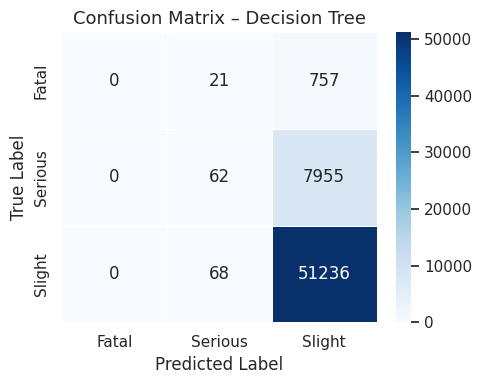

In [33]:
# ----------------------------------------------------------------
# MODEL 5 – DECISION TREE CLASSIFIER
# ----------------------------------------------------------------
# Why: Fully interpretable – produces a flowchart of decisions
#      that can be visualised and explained to non-technical
#      stakeholders. Prone to overfitting if unconstrained.
# Key params:
#   max_depth        = limits tree growth to prevent overfitting
#   min_samples_split= minimum samples needed to split a node
#   min_samples_leaf = minimum samples required at a leaf node
#   criterion        = "gini" uses Gini impurity to measure splits
# ----------------------------------------------------------------

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth         = 6,        # limit depth to control overfitting
    min_samples_split = 10,       # node must have ≥10 samples to split
    min_samples_leaf  = 5,        # each leaf must have ≥5 samples
    criterion         = "gini",   # Gini impurity for split quality
    random_state      = RANDOM_STATE
)

# Train the decision tree
dt.fit(X_train, y_train)

# 5-Fold Cross-Validation
dt_cv = cross_val_score(dt, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"Decision Tree – CV Accuracy: {dt_cv.mean():.4f} ± {dt_cv.std():.4f}")

# Full evaluation: metrics + confusion matrix
y_pred_dt = evaluate_model(dt, X_test, y_test, "Decision Tree")

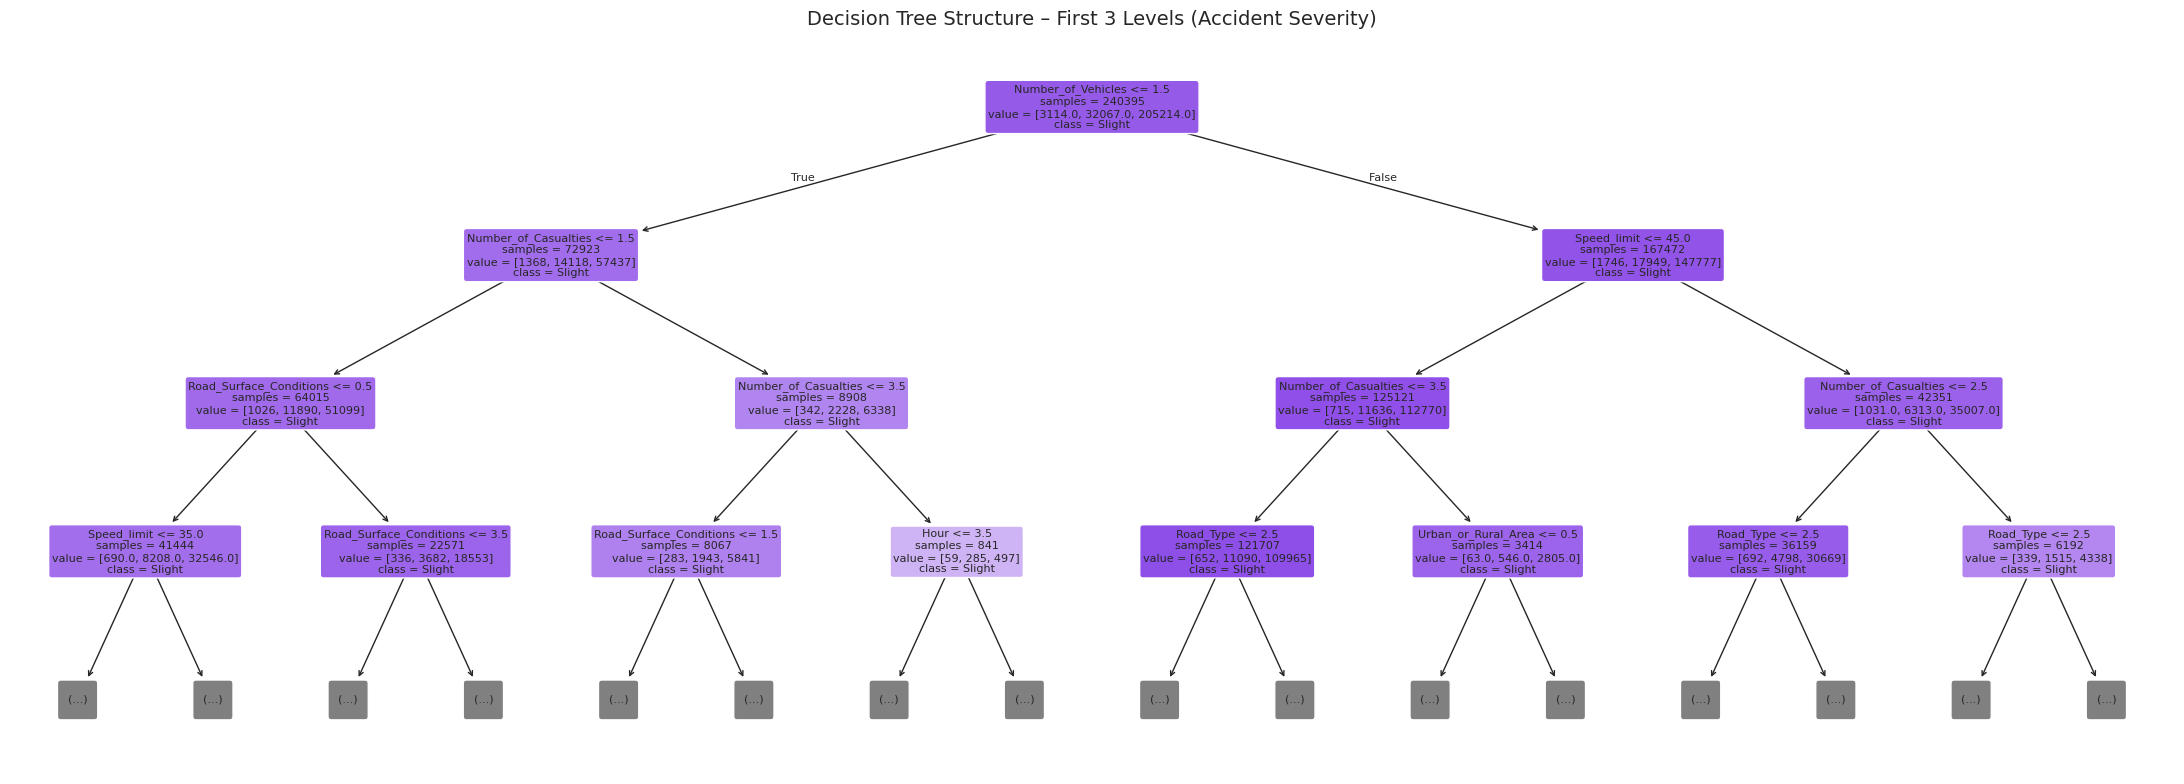

In [34]:
# ── Decision Tree: Visual Diagram (first 3 levels) ────────
# plot_tree renders the decision flowchart; we cap at depth=3
# so it remains readable in the notebook output

from sklearn.tree import plot_tree

plt.figure(figsize=(22, 8))
plot_tree(
    dt,
    feature_names = feature_cols,      # label each split with feature name
    class_names   = le_target.classes_,# label leaves with class names
    filled        = True,              # colour nodes by majority class
    max_depth     = 3,                 # show only the first 3 levels
    fontsize      = 8,
    impurity      = False,             # hide Gini value for cleaner view
    rounded       = True               # rounded node boxes
)
plt.title(
    "Decision Tree Structure – First 3 Levels (Accident Severity)",
    fontsize=14
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_222/1348902785.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dt_importances.values, y=dt_importances.index, palette="Greens_r")


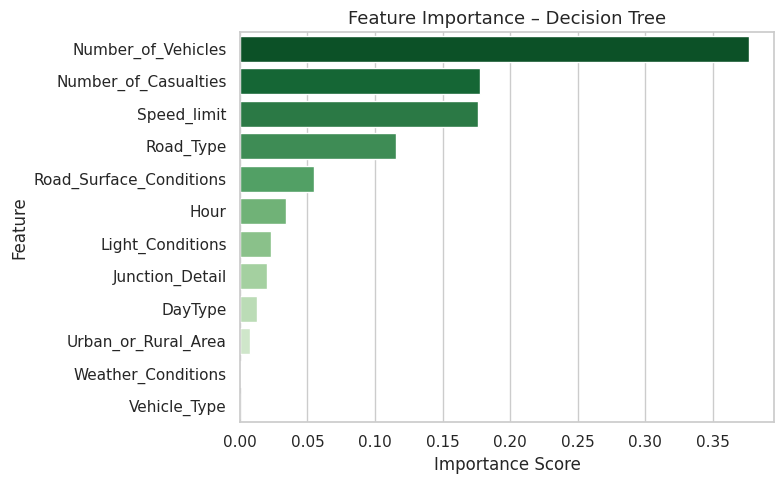

In [35]:
# ── Decision Tree: Feature Importance ─────────────────────────
# The importance of a feature = total reduction in Gini impurity
# weighted by the number of samples it splits

dt_importances = pd.Series(
    dt.feature_importances_,
    index = feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=dt_importances.values, y=dt_importances.index, palette="Greens_r")
plt.title("Feature Importance – Decision Tree", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


##Model 6 – SVM

In [ ]:
# ----------------------------------------------------------------
# MODEL 6 – SUPPORT VECTOR MACHINE (SVM – RBF Kernel)
# ----------------------------------------------------------------
# Why: Finds the optimal hyperplane separating severity classes
#      in a high-dimensional feature space. The RBF kernel maps
#      data into a higher dimension to handle non-linear patterns.
# IMPORTANT: SVM is sensitive to feature scale → StandardScaler
#            was applied in Cell 6 before this step.
# Key params:
#   kernel = "rbf"  → Radial Basis Function for non-linear data
#   C      = 1.0    → Regularisation (higher = tighter fit, more risk)
#   gamma  = "scale"→ kernel bandwidth auto-scaled from feature variance
# ----------------------------------------------------------------

from sklearn.svm import SVC

svm = SVC(
    kernel                 = "rbf",   # non-linear kernel
    C                      = 1.0,     # regularisation parameter
    gamma                  = "scale", # auto kernel coefficient
    decision_function_shape= "ovr",   # One-vs-Rest for multi-class
    random_state           = RANDOM_STATE
)

# Train on SCALED training data (SVM requires standardised features)
svm.fit(X_train_scaled, y_train)

# 5-Fold Cross-Validation on scaled full dataset
svm_cv = cross_val_score(svm, X_scaled, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"SVM (RBF) – CV Accuracy: {svm_cv.mean():.4f} ± {svm_cv.std():.4f}")

# Evaluate on SCALED test set
y_pred_svm = evaluate_model(svm, X_test_scaled, y_test, "SVM (RBF Kernel)")

##Final Comparison – All 6 Models


In [ ]:
# ----------------------------------------------------------------
# FINAL COMPARISON – ALL 6 MODELS
# ----------------------------------------------------------------

# 14.1 Metrics Comparison Table
# results_list was populated inside evaluate_model() for each model
results_df = (
    pd.DataFrame(results_list)
    .sort_values("F1_Score", ascending=False)  # rank by F1
    .reset_index(drop=True)
)

# Style the table: highlight max value in each metric column
styled_results = (
    results_df.style
    .highlight_max(
        subset  = ["Accuracy","Precision","Recall","F1_Score"],
        color   = "#c8e6c9"   # light green for best values
    )
    .format({
        "Accuracy"  : "{:.4f}",
        "Precision" : "{:.4f}",
        "Recall"    : "{:.4f}",
        "F1_Score"  : "{:.4f}"
    })
    .set_caption("Model Performance Summary – All 6 Models (sorted by F1)")
)

display(styled_results)


In [ ]:
# 14.2 Cross-Validation Summary Table

cv_df = pd.DataFrame({
    "Model"   : [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "KNN (k=7)",
        "Decision Tree",
        "SVM (RBF Kernel)"
    ],
    "CV_Mean" : [
        lr_cv.mean(),
        rf_cv.mean(),
        gbr_cv.mean(),
        knn_cv.mean(),
        dt_cv.mean(),
        svm_cv.mean()
    ],
    "CV_Std"  : [
        lr_cv.std(),
        rf_cv.std(),
        gbr_cv.std(),
        knn_cv.std(),
        dt_cv.std(),
        svm_cv.std()
    ]
}).sort_values("CV_Mean", ascending=False).reset_index(drop=True)

print("5-Fold Cross-Validation Results:")
display(cv_df.style
        .highlight_max(subset=["CV_Mean"], color="#c8e6c9")
        .format({"CV_Mean": "{:.4f}", "CV_Std": "{:.4f}"})
        .set_caption("Cross-Validation Accuracy – All 6 Models"))


In [ ]:
# 14.3 Grouped Bar Chart – Accuracy, Precision, Recall, F1
# One group of bars per model, one bar per metric

metrics_cols   = ["Accuracy", "Precision", "Recall", "F1_Score"]
results_melted = results_df.melt(
    id_vars    = "Model",
    value_vars = metrics_cols,
    var_name   = "Metric",
    value_name = "Score"
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data    = results_melted,
    x       = "Model",
    y       = "Score",
    hue     = "Metric",
    palette = "Set2"
)
plt.title("All 6 Models – Accuracy, Precision, Recall, F1 Comparison", fontsize=14)
plt.ylabel("Score (0 – 1)")
plt.ylim(0, 1.12)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="upper right", title="Metric")
plt.tight_layout()
plt.show()


In [ ]:
# 14.4 Cross-Validation Bar Chart with Error Bars
# Error bars represent ±1 standard deviation across 5 folds

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data    = cv_df,
    x       = "Model",
    y       = "CV_Mean",
    palette = "coolwarm"
)

# Add ±1 std error bars on top of bars
plt.errorbar(
    x         = range(len(cv_df)),
    y         = cv_df["CV_Mean"],
    yerr      = cv_df["CV_Std"],
    fmt       = "none",
    color     = "black",
    capsize   = 6,
    linewidth = 1.5
)

plt.title("5-Fold Cross-Validation Accuracy – All 6 Models", fontsize=14)
plt.ylabel("CV Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# 14.5 Performance Heatmap – Best visual for reports & portfolios
# Rows = models, Columns = metrics, cells = score value

heatmap_data = (
    results_df
    .set_index("Model")
    [["Accuracy", "Precision", "Recall", "F1_Score"]]
)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_data,
    annot      = True,           # display numeric values inside cells
    fmt        = ".3f",          # 3 decimal places
    cmap       = "YlGn",         # yellow → green colour scale
    linewidths = 0.5,            # thin lines between cells
    vmin       = 0,              # colour scale min
    vmax       = 1               # colour scale max
)
plt.title("Model Performance Heatmap – All 6 Models", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


In [ ]:
# 14.6 F1-Score Ranking – Single metric quick view

plt.figure(figsize=(9, 4))
sns.barplot(
    data    = results_df,
    x       = "F1_Score",
    y       = "Model",
    palette = "RdYlGn"           # red (low) → green (high)
)
plt.title("Model Ranking by Weighted F1-Score", fontsize=14)
plt.xlabel("F1-Score (weighted)")
plt.ylabel("")
plt.xlim(0, 1.05)

# Annotate each bar with its F1 value
for i, row in results_df.iterrows():
    plt.text(
        row["F1_Score"] + 0.005,   # slightly right of bar end
        i,                          # y position
        f"{row['F1_Score']:.4f}",
        va="center",
        fontsize=10
    )

plt.

##